Name: Rahul Gupta

Class: 4 MCA B

Register No: 2547242

---

### KNN Distance

Dataset Creation

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# 1. Set a random seed so you get the exact same numbers every time
np.random.seed(42)

# 2. Generate 46 normal points (values between 1 and 10)
X_normal = np.random.uniform(1, 10, (46, 2))

# 3. Generate 4 outlier points further away (values between 12 and 15)
X_outliers = np.random.uniform(12, 15, (4, 2))

# 4. Combine them into a single dataset of 50 points
X = np.vstack((X_normal, X_outliers))

# 5. Assign labels ('A' or 'B') based on where they lie on the grid
labels = []
for point in X:
    if point[0] + point[1] < 11:
        labels.append('A')
    else:
        labels.append('B')
labels = np.array(labels)

Visualizing Custom Dataset

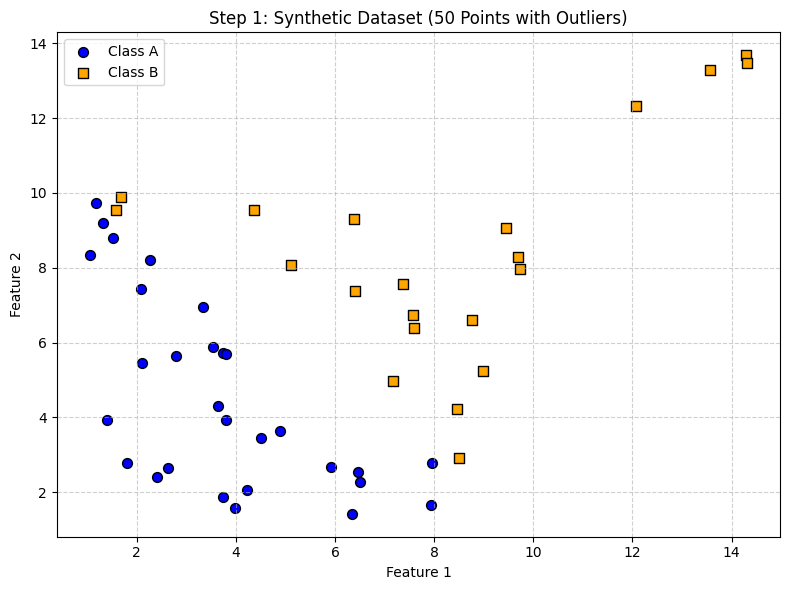

In [6]:
# Create the first plot
fig, ax = plt.subplots(figsize=(8, 6))

# Plot Class A and Class B separately with different colors
for label, color, marker in zip(['A', 'B'], ['blue', 'orange'], ['o', 's']):
    mask = labels == label
    ax.scatter(X[mask, 0], X[mask, 1], c=color, marker=marker, label=f'Class {label}', s=50, edgecolors='k')

ax.set_title('Step 1: Synthetic Dataset (50 Points with Outliers)')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend()
plt.tight_layout()
plt.savefig('step1_dataset.png')  # Saves the graph

Setting Up the k-NN Predictor

In [7]:
# Define our unknown test point and set k=5
test_point = np.array([5.5, 5.0])
k = 5

# Distance function (Euclidean distance)
def euclidean_distance(p1, p2):
    return np.sqrt(np.sum((p1 - p2) ** 2))

# Calculate the distance from our test point to all 50 training points
distances = []
for i in range(len(X)):
    dist = euclidean_distance(test_point, X[i])
    distances.append((dist, labels[i], X[i]))

# Sort them from closest to furthest
distances.sort(key=lambda x: x[0])

# Snatch the top 'k' closest neighbors
neighbors = distances[:k]

# Count the majority vote
neighbor_labels = [label for _, label, _ in neighbors]
prediction = Counter(neighbor_labels).most_common(1)[0][0]

print(f"The 5 closest neighbors voted: {neighbor_labels}")
print(f"The predicted class for the test point is: '{prediction}'")

The 5 closest neighbors voted: [np.str_('A'), np.str_('B'), np.str_('A'), np.str_('A'), np.str_('A')]
The predicted class for the test point is: 'A'


Visualizing the k-NN Voting Process

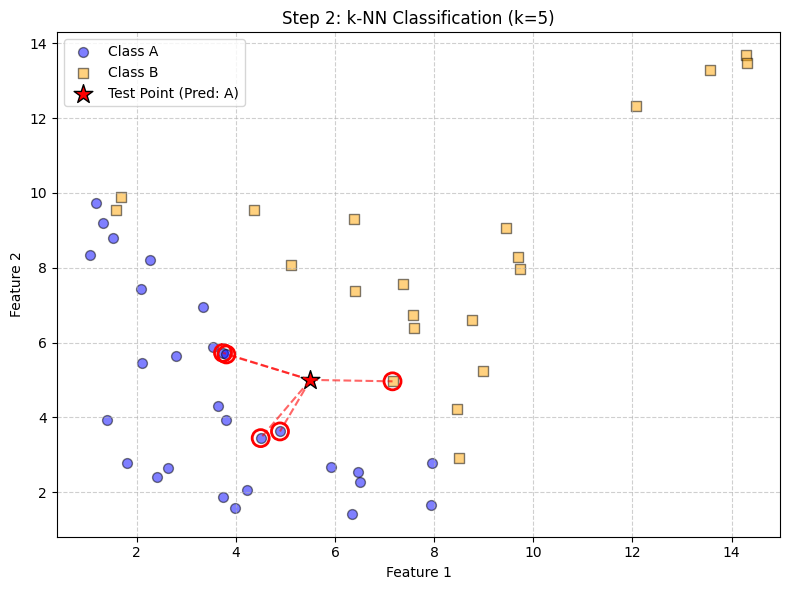

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))

# Plot the background data points faintly
for label, color, marker in zip(['A', 'B'], ['blue', 'orange'], ['o', 's']):
    mask = labels == label
    ax.scatter(X[mask, 0], X[mask, 1], c=color, marker=marker, label=f'Class {label}', s=50, edgecolors='k', alpha=0.5)

# Highlight our mystery test point with a large red star
ax.scatter(test_point[0], test_point[1], c='red', marker='*', s=200, label=f'Test Point (Pred: {prediction})', edgecolors='k')

# Draw lines to the 5 nearest neighbors and circle them
for dist, label, pt in neighbors:
    ax.plot([test_point[0], pt[0]], [test_point[1], pt[1]], 'r--', alpha=0.6)
    ax.scatter(pt[0], pt[1], facecolors='none', edgecolors='red', s=150, linewidths=2)

ax.set_title(f'Step 2: k-NN Classification (k={k})')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend()
plt.tight_layout()
plt.savefig('step2_knn_prediction.png')  # Saves the graph